# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [11]:
import math
import numpy as np
from scipy.integrate import odeint
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

In [12]:
# Generate the data using the VF-b modified FHN equations
def fhn_vf_b(state, t, mu = 1.0, alpha = 0.2, beta = 1.1, gamma = 0.31, theta = -0.05, delta = 1.0, eps = 0.005):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v # Note - the cardiac version has -u*v instead of -v. For some reason, can only get the full domain with -v, so use it for now.
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)

    # Add time-dependent voltage perturbation
    u_dot += 0.1*(math.sin(0.0025*t))**2
    return u_dot, v_dot

# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,3000,dt)
x_0_vf_b = np.array([0.5,0])
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b)

Now, let's try fitting the above with some non-autonomous terms included:

In [13]:
# Run SINDy on VF-FHN w/ time-varying terms
opt_vf_b = ps.SSR(alpha=0.5)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = -0.00033 1 + 0.18700 u + 0.04456 v + -0.12179 u^2 + -1.82022 u v + -0.89901 v^2 + -0.05377 u^3 + 1.51210 u^2 v + 1.75554 u v^2 + 3.27209 v^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 v + -0.00500 u^2


Actual equations for comparison:

\begin{align}
    \dot{u} = - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} = -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

In [14]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])
             
plot1 = px.scatter(df_states_vf_b, x='u', y='v', color=df_states_vf_b['v'])
plot1.update_traces(marker_size = 1.5)

[0.5, 0.50075091730342, 0.5015036695672997, 0.5022582577012136, 0.503014682679131, 0.5037729447504983, 0.5045330447706341, 0.5052949836114066, 0.506058762144684, 0.5068243812423345]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


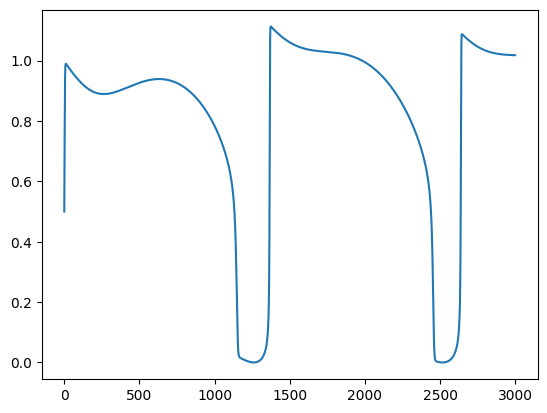

In [15]:
# Plot result - time domain - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)